# Hierarchical Risk Parity (HRP)

**Docker image**: `ml4t`

This notebook demonstrates Hierarchical Risk Parity, a modern portfolio construction
method developed by Marcos López de Prado that reduces sensitivity to noisy covariance
estimates through clustering, quasi-diagonalization, and recursive bisection.

**Learning Objectives**:
- Understand why classical MVO can be fragile in practice (the "Markowitz Curse")
- Implement the three steps of HRP: clustering, quasi-diagonalization, recursive bisection
- Visualize the asset hierarchy with dendrograms
- Run walk-forward backtests comparing HRP to shrinkage MVO and to heuristic allocators, and
  read the ranking against the assets-to-observations ratio that decides when HRP helps

**Book Reference**: Chapter 17, Section 17.6 (Hierarchical Risk Parity)

**Prerequisites**: `02_mean_variance_optimization`, ETF price data

## 1. Setup and Imports

In [1]:
"""Hierarchical Risk Parity: cluster assets and allocate using inverse variance."""

import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.visualization import create_portfolio_dashboard
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf

from case_studies.utils.backtest_loaders import compute_allocator_metrics
from case_studies.utils.registry.queries import load_prediction_index
from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

In [2]:
# Production defaults; Papermill overrides these values for CI testing
START_DATE = "2010-01-01"
SEED = 42

In [3]:
set_global_seeds(SEED)

# Track allocator fallbacks across the walk-forward backtest.
fallback_count: dict[str, int] = {}

## 2. Where Mean-Variance Optimization Is Fragile

Mean-variance optimization inverts an estimated covariance matrix. Inversion amplifies the
smallest eigenvalues, which are the ones the sample estimates worst, so small errors in the
inputs can move the weights a long way. The fragility grows with the ratio of assets to
observations: with $N$ assets and $T$ periods the sample covariance is singular once $N > T$
and poorly conditioned well before that.

HRP is one response - never invert. Shrinkage is another - keep inverting, but pull the
estimate toward a well-conditioned target first. This notebook runs both, and section 12 reads
the comparison against the ratio $N/T$. That ratio is one contributor to how hard the estimate
is, not the thing that decides which response to use: conditioning also depends on how the assets
co-move, and a low $N/T$ over highly correlated assets can be worse conditioned than a higher one
over independent ones. A single window over one universe cannot establish when either allocator
helps in general; what section 12 shows is which did better here. See §17.6.

## 3. Data Acquisition

The 15 named ETFs form a fixed teaching universe. It is not a point-in-time
membership reconstruction, so the static examples and walk-forward comparison are
conditional on this ex-post universe and must not be read as an unbiased universe-selection test.

In [4]:
# Diversified ETF universe
ETF_UNIVERSE = {
    # US Equity
    "SPY": "S&P 500",
    "QQQ": "NASDAQ 100",
    "IWM": "Russell 2000",
    # International Equity
    "EFA": "EAFE Developed",
    "EEM": "Emerging Markets",
    # Fixed Income
    "AGG": "US Aggregate Bond",
    "TLT": "Long Treasury",
    "HYG": "High Yield",
    # Alternatives
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Commodities",
    # Sectors
    "XLF": "Financials",
    "XLE": "Energy",
    "XLK": "Technology",
    "XLV": "Healthcare",
}

SYMBOLS = list(ETF_UNIVERSE.keys())
END_DATE = "2024-01-01"

In [5]:
# Load data from canonical ETFs
print("Loading ETF data...")
etf_data = load_etfs()
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
)

close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
returns = close_prices.pct_change().dropna()
print(f"Loaded {len(returns):,} days for {close_prices.shape[1]} ETFs")

Loading ETF data...
Loaded 3,521 days for 15 ETFs


## 4. The HRP Algorithm

HRP works in three steps:

### Step 1: Tree Clustering
Build a hierarchy of assets based on their correlation structure using
agglomerative clustering.

$$d_{ij} = \sqrt{\frac{1-\rho_{ij}}{2}}$$

### Step 2: Quasi-Diagonalization
Reorder the covariance matrix according to the clustering hierarchy
to group similar assets together.

### Step 3: Recursive Bisection
Allocate risk by recursively splitting the portfolio in half,
with weights inversely proportional to the cluster variance.

In [6]:
def correlation_distance(corr_matrix: np.ndarray) -> np.ndarray:
    """Convert a correlation matrix to a bounded distance matrix."""
    return np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0.0, 1.0))

#### Step 1: Hierarchical Clustering

In [7]:
def cluster_assets(returns: pd.DataFrame, method: str = "ward") -> np.ndarray:
    """
    Perform hierarchical clustering on assets based on correlation distance.

    Args:
        returns: DataFrame of asset returns
        method: Linkage method ('ward', 'single', 'complete', 'average')

    Returns:
        linkage matrix
    """
    corr = returns.corr().values
    dist = correlation_distance(corr)
    # Convert to condensed distance matrix (upper triangle)
    dist_condensed = squareform(dist, checks=False)
    return linkage(dist_condensed, method=method)

#### Step 2: Leaf Ordering

In [8]:
def get_quasi_diagonal_order(link: np.ndarray) -> list[int]:
    """
    Get the quasi-diagonal ordering from linkage matrix.

    This reorders assets so that similar ones are adjacent.
    """
    return list(leaves_list(link))

The variance of a sub-portfolio held at inverse-variance weights, which is the number each
split compares its two halves on.

In [9]:
def cluster_variance(cov: np.ndarray, indices: list[int]) -> float:
    """Compute cluster variance using inverse-variance weights within a subset."""
    if len(indices) == 1:
        return float(cov[indices[0], indices[0]])
    c = cov[np.ix_(indices, indices)]
    ivp = 1 / np.diag(c)
    ivp /= ivp.sum()
    return float(np.dot(ivp, np.dot(c, ivp)))

#### Step 3: Recursive Bisection Allocation

In [10]:
def recursive_bisection(
    cov: np.ndarray,
    sorted_idx: list[int],
) -> np.ndarray:
    """Allocate weights by recursively splitting ordered clusters."""
    n = len(sorted_idx)
    weights = np.ones(n)
    sorted_position = {original: position for position, original in enumerate(sorted_idx)}
    clusters = [sorted_idx]

    while clusters:
        new_clusters = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue

            mid = len(cluster) // 2
            left = cluster[:mid]
            right = cluster[mid:]

            left_var = cluster_variance(cov, left)
            right_var = cluster_variance(cov, right)

            alpha = 1 - left_var / (left_var + right_var)
            weights[[sorted_position[i] for i in left]] *= alpha
            weights[[sorted_position[i] for i in right]] *= 1 - alpha

            if len(left) > 1:
                new_clusters.append(left)
            if len(right) > 1:
                new_clusters.append(right)

        clusters = new_clusters

    final_weights = np.zeros(n)
    final_weights[np.asarray(sorted_idx)] = weights

    return final_weights / final_weights.sum()

The three steps in order, from a covariance matrix to a weight vector.

In [11]:
def hrp_portfolio(returns: pd.DataFrame) -> np.ndarray:
    """
    Compute HRP portfolio weights.

    Args:
        returns: DataFrame of asset returns

    Returns:
        Array of portfolio weights
    """
    # Step 1: Cluster
    link = cluster_assets(returns)

    # Step 2: Quasi-diagonalize
    sorted_idx = get_quasi_diagonal_order(link)

    # Step 3: Recursive bisection
    cov = returns.cov().values
    weights = recursive_bisection(cov, sorted_idx)

    return weights

## 5. Visualizing the Asset Hierarchy

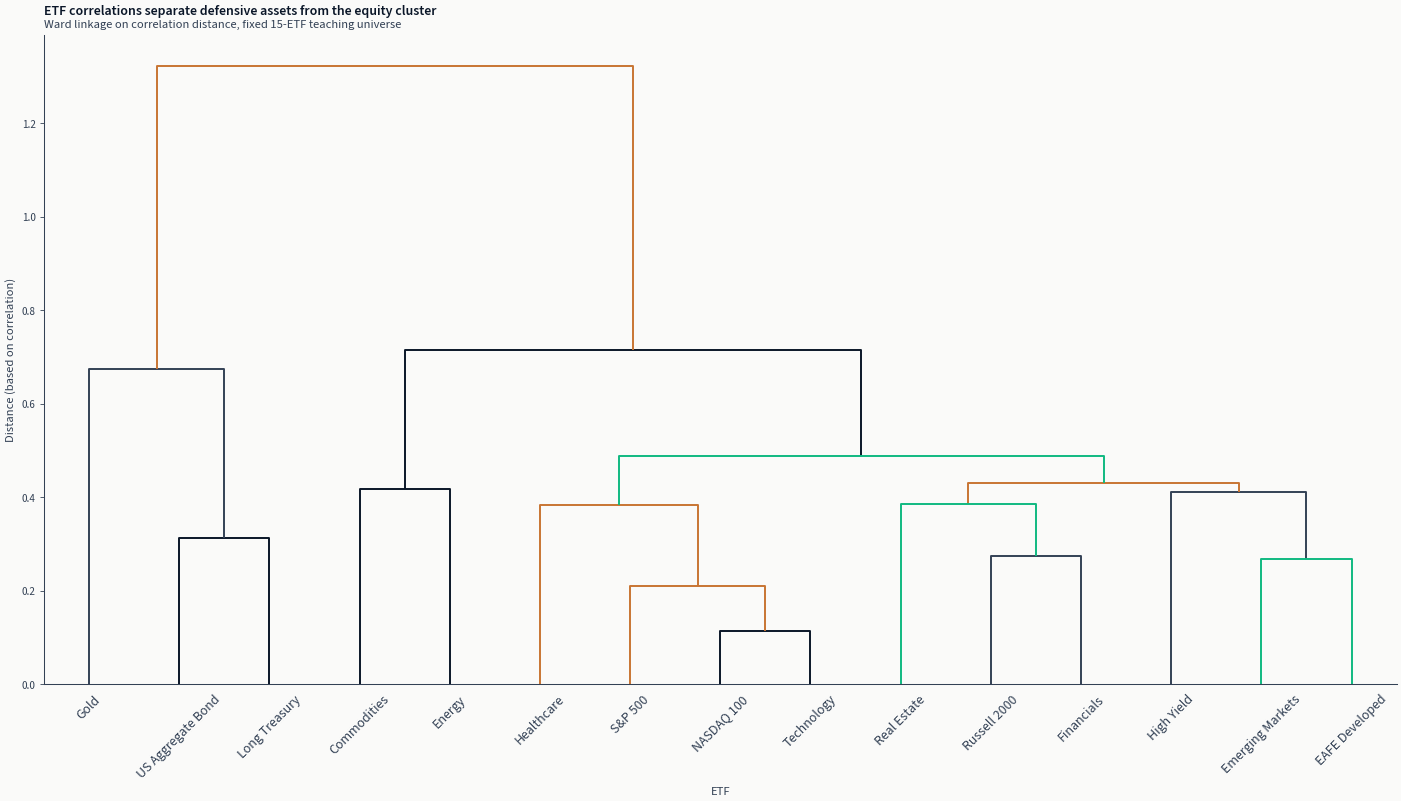

In [12]:
# Compute linkage for visualization
link = cluster_assets(returns)
branch_colors = [COLORS["blue"], COLORS["copper"], COLORS["positive"], COLORS["neutral"]]

# Create dendrogram
fig, ax = plt.subplots(figsize=(14, 8))
dendrogram(
    link,
    labels=[ETF_UNIVERSE.get(s, s) for s in returns.columns],
    leaf_rotation=45,
    leaf_font_size=10,
    link_color_func=lambda node_id: branch_colors[(node_id - len(returns.columns)) % 4],
    ax=ax,
)
ax.set_ylabel("Distance (based on correlation)")
ax.set_xlabel("ETF")
add_message_title(
    ax,
    "ETF correlations separate defensive assets from the equity cluster",
    subtitle="Ward linkage on correlation distance, fixed 15-ETF teaching universe",
)
plt.show()

### The hierarchy the algorithm builds

In [13]:
def plotly_dendrogram(link, labels, title="Asset Hierarchy"):
    """Create interactive dendrogram with Plotly."""
    # Get dendrogram coordinates
    dn = dendrogram(link, labels=labels, no_plot=True)

    # Create traces
    traces = []
    for i in range(len(dn["icoord"])):
        traces.append(
            go.Scatter(
                x=dn["icoord"][i],
                y=dn["dcoord"][i],
                mode="lines",
                line=dict(color=COLORS["blue"], width=1.5),
                hoverinfo="skip",
            )
        )

    # Create figure
    fig = go.Figure(data=traces)

    # Add labels at bottom
    fig.update_layout(
        title=title,
        xaxis=dict(
            tickmode="array",
            tickvals=list(range(5, 10 * len(labels), 10)),
            ticktext=[labels[i] for i in dn["leaves"]],
            tickangle=45,
            title="ETF",
        ),
        yaxis_title="Correlation Distance",
        height=500,
        showlegend=False,
    )

    return fig

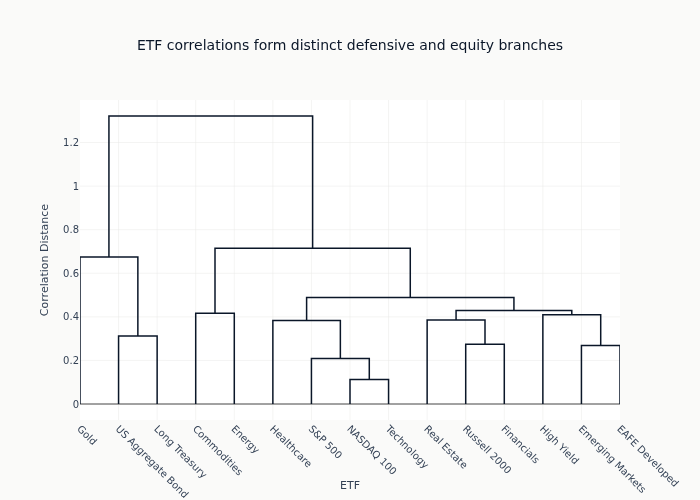

In [14]:
labels = [ETF_UNIVERSE.get(s, s) for s in returns.columns]
fig = plotly_dendrogram(
    link, labels, "ETF correlations form distinct defensive and equity branches"
)
fig.show()

## 6. Quasi-Diagonal Covariance Matrix

After clustering, we reorder the covariance matrix to reveal the block structure.

In [15]:
# Get quasi-diagonal ordering
sorted_idx = get_quasi_diagonal_order(link)
sorted_symbols = [returns.columns[i] for i in sorted_idx]
sorted_labels = [ETF_UNIVERSE.get(s, s) for s in sorted_symbols]

# Reorder covariance matrix
cov_original = returns.cov()
cov_reordered = cov_original.iloc[sorted_idx, sorted_idx]
cov_colorscale = [
    [0.0, COLORS["negative"]],
    [0.5, COLORS["silver"]],
    [1.0, COLORS["blue"]],
]

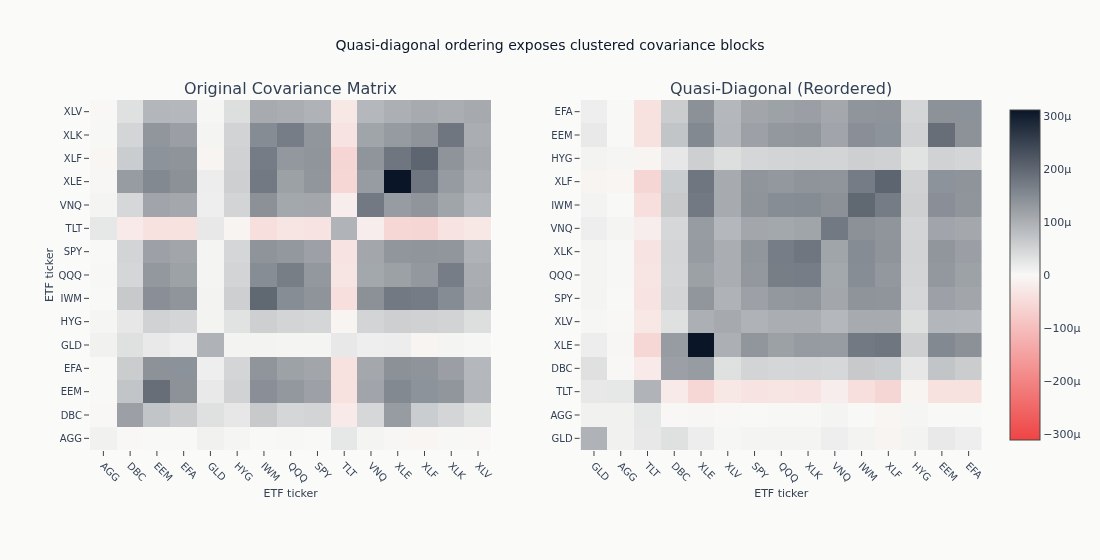

In [16]:
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Original Covariance Matrix", "Quasi-Diagonal (Reordered)"]
)
fig.add_trace(
    go.Heatmap(
        z=cov_original.values,
        x=cov_original.columns,
        y=cov_original.index,
        colorscale=cov_colorscale,
        zmid=0,
        showscale=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Heatmap(
        z=cov_reordered.values,
        x=sorted_symbols,
        y=sorted_symbols,
        colorscale=cov_colorscale,
        zmid=0,
        showscale=True,
    ),
    row=1,
    col=2,
)
fig.update_layout(
    title="Quasi-diagonal ordering exposes clustered covariance blocks",
    height=560,
    width=1100,
    margin=dict(l=90, r=90, b=110, t=100),
)
fig.update_xaxes(tickangle=45, tickfont_size=10, automargin=True)
fig.update_yaxes(tickfont_size=10, automargin=True)
fig.update_xaxes(title_text="ETF ticker", row=1, col=1)
fig.update_xaxes(title_text="ETF ticker", row=1, col=2)
fig.update_yaxes(title_text="ETF ticker", row=1, col=1)
fig.show()

## 7. Compute HRP Weights

In [17]:
# Compute HRP weights
hrp_weights = hrp_portfolio(returns)

# Create weights DataFrame
weights_df = pd.DataFrame(
    {
        "Symbol": returns.columns,
        "Name": [ETF_UNIVERSE.get(s, s) for s in returns.columns],
        "HRP Weight": hrp_weights,
    }
)
weights_df = weights_df.sort_values("HRP Weight", ascending=False)

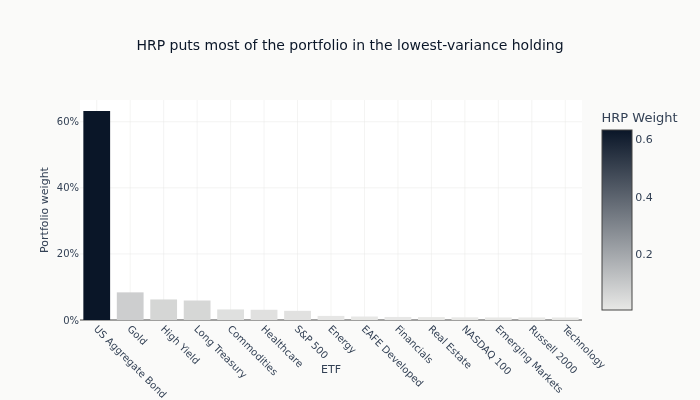

In [18]:
# Visualization
fig = px.bar(
    weights_df,
    x="Name",
    y="HRP Weight",
    title="HRP puts most of the portfolio in the lowest-variance holding",
    color="HRP Weight",
    color_continuous_scale=[COLORS["silver_muted"], COLORS["blue"]],
)
fig.update_layout(
    height=400,
    xaxis_tickangle=45,
    xaxis_title="ETF",
    yaxis_title="Portfolio weight",
    yaxis_tickformat=".0%",
)
fig.show()

### Where That Concentration Comes From

HRP is introduced as the answer to the concentrated portfolios that mean-variance optimization
produces, so a single dominant weight deserves an explanation rather than a shrug. It follows
from the algorithm as specified.

Recursive bisection splits the *ordered list* in half by count at every level. It does not cut
the tree at the linkage's own cluster boundaries, so the halves it forms need not be the
clusters the dendrogram shows. Each half then receives capital inversely to its cluster
variance. Two splits are enough to see the effect.

In [19]:
def trace_bisection(cov: np.ndarray, sorted_idx: list[int], columns, levels: int = 2) -> None:
    """Print the halves, their annualized cluster variances, and the resulting split share."""
    clusters, depth = [sorted_idx], 0
    while clusters and depth < levels:
        next_clusters = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid = len(cluster) // 2
            left, right = cluster[:mid], cluster[mid:]
            left_var, right_var = cluster_variance(cov, left), cluster_variance(cov, right)
            alpha = 1 - left_var / (left_var + right_var)
            print(f"  split at depth {depth}:")
            print(
                f"    {[columns[i] for i in left]}\n"
                f"      annualized cluster variance {left_var * 252:.4f} -> {alpha:.1%} of the branch"
            )
            print(
                f"    {[columns[i] for i in right]}\n"
                f"      annualized cluster variance {right_var * 252:.4f} -> {1 - alpha:.1%} of the branch"
            )
            if len(left) > 1:
                next_clusters.append(left)
            if len(right) > 1:
                next_clusters.append(right)
        clusters = next_clusters
        depth += 1


print("First two levels of the recursive bisection:")
trace_bisection(returns.cov().values, get_quasi_diagonal_order(link), list(returns.columns))
print()
print(f"Weight in the single largest holding: {weights_df['HRP Weight'].max():.1%}")
print(f"Weight in the three largest: {weights_df['HRP Weight'].nlargest(3).sum():.1%}")

First two levels of the recursive bisection:
  split at depth 0:
    ['GLD', 'AGG', 'TLT', 'DBC', 'XLE', 'XLV', 'SPY']
      annualized cluster variance 0.0025 -> 87.8% of the branch
    ['QQQ', 'XLK', 'VNQ', 'IWM', 'XLF', 'HYG', 'EEM', 'EFA']
      annualized cluster variance 0.0183 -> 12.2% of the branch
  split at depth 1:
    ['GLD', 'AGG', 'TLT']
      annualized cluster variance 0.0030 -> 88.3% of the branch
    ['DBC', 'XLE', 'XLV', 'SPY']
      annualized cluster variance 0.0225 -> 11.7% of the branch
  split at depth 1:
    ['QQQ', 'XLK', 'VNQ', 'IWM']
      annualized cluster variance 0.0374 -> 26.4% of the branch
    ['XLF', 'HYG', 'EEM', 'EFA']
      annualized cluster variance 0.0134 -> 73.6% of the branch

Weight in the single largest holding: 63.2%
Weight in the three largest: 77.8%


The low-variance half takes most of the capital at both splits, and the shares multiply. Bonds and gold
end up holding most of the portfolio, and within them the lowest-volatility holding takes most
of what is left.

This is inverse-variance allocation doing exactly what it is defined to do, not a bug. But it
means HRP is not concentration-free: it concentrates on the *low-variance* assets rather than on
whichever assets the covariance inverse happens to favor. Whether that is an improvement depends
on whether low realized variance in the estimation window is a better guide to the future than
the inverse covariance is - a question the walk-forward comparison below can address and this
static example cannot.

## 8. Comparison: HRP vs Other Methods

In [20]:
def inverse_volatility_weights(returns: pd.DataFrame) -> np.ndarray:
    """Inverse volatility (risk parity) weights."""
    vols = returns.std().values
    inv_vols = 1 / vols
    return inv_vols / inv_vols.sum()

#### Equal-Weight Baseline

In [21]:
def equal_weights(n: int) -> np.ndarray:
    """Equal weights."""
    return np.ones(n) / n

#### Minimum-Variance Baseline

The long-only projection starts from
$w = \Sigma^{-1}\mathbf{1}/(\mathbf{1}^{\top}\Sigma^{-1}\mathbf{1})$,
clips negative weights, and renormalizes the remaining capital.

In [22]:
def minimum_variance_weights(returns: pd.DataFrame) -> np.ndarray:
    """Minimum variance portfolio (no expected returns input)."""
    cov = returns.cov().values
    n = len(returns.columns)

    try:
        cov_inv = np.linalg.inv(cov)
        ones = np.ones(n)
        weights = cov_inv @ ones
        weights /= weights.sum()
        # Long-only projection: clip negatives, then renormalize so weights sum to 1
        weights = np.clip(weights, 0, None)
        total = weights.sum()
        return weights / total if total > 0 else equal_weights(n)
    except np.linalg.LinAlgError:
        return equal_weights(n)

#### Ledoit-Wolf Shrinkage Baseline

In [23]:
def mvo_shrinkage_weights(returns: pd.DataFrame) -> np.ndarray:
    """MVO with Ledoit-Wolf shrinkage."""
    # Use Ledoit-Wolf for robust covariance
    lw = LedoitWolf().fit(returns)
    cov_shrunk = lw.covariance_

    # Minimum variance with shrunk covariance
    n = len(returns.columns)
    try:
        cov_inv = np.linalg.inv(cov_shrunk)
        ones = np.ones(n)
        weights = cov_inv @ ones
        weights /= weights.sum()
        # Long-only projection: clip negatives, then renormalize so weights sum to 1
        weights = np.clip(weights, 0, None)
        total = weights.sum()
        return weights / total if total > 0 else equal_weights(n)
    except np.linalg.LinAlgError:
        return equal_weights(n)

In [24]:
# Compute all weights
n_assets = len(returns.columns)

all_weights = pd.DataFrame(
    {
        "Symbol": returns.columns,
        "Name": [ETF_UNIVERSE.get(s, s) for s in returns.columns],
        "Equal": equal_weights(n_assets),
        "Inv Vol": inverse_volatility_weights(returns),
        "Min Var (LW)": mvo_shrinkage_weights(returns),
        "HRP": hrp_weights,
    }
)

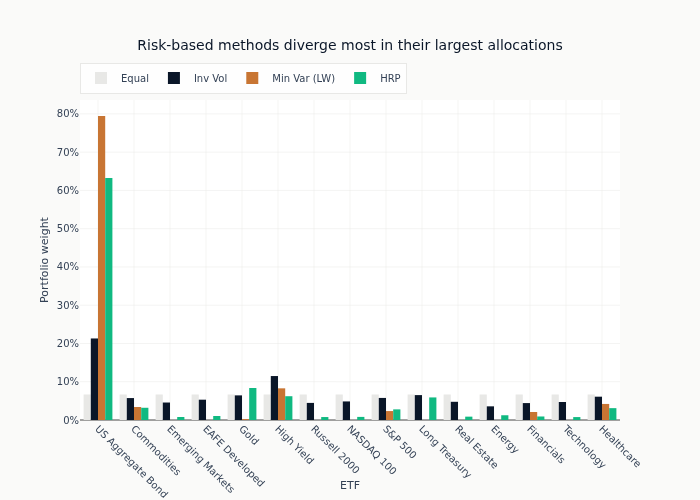

In [25]:
# Visualization: Weight comparison
fig = go.Figure()

methods = ["Equal", "Inv Vol", "Min Var (LW)", "HRP"]
colors = [COLORS["silver_muted"], COLORS["blue"], COLORS["copper"], COLORS["positive"]]

for method, color in zip(methods, colors, strict=False):
    fig.add_trace(
        go.Bar(
            name=method,
            x=all_weights["Name"],
            y=all_weights[method],
            marker_color=color,
        )
    )

fig.update_layout(
    title="Risk-based methods diverge most in their largest allocations",
    barmode="group",
    xaxis_tickangle=45,
    xaxis_title="ETF",
    yaxis_title="Portfolio weight",
    yaxis_tickformat=".0%",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

## 9. Walk-Forward Backtest with ML Predictions

The previous sections demonstrated *how* HRP allocates capital given a
covariance matrix. We now apply it inside a realistic trading strategy:

1. Load the ETF case-study GBM walk-forward predictions (Chapter 12).
2. At each rebalance date, use the latest available prediction to *select* the
   top-$N$ assets.
3. Apply HRP (and the other methods) to the selected subset using only
   historical returns for covariance estimation.

Asset selection is driven by a walk-forward validation signal, while the
allocator only sees information available at the rebalance date. The target
becomes effective on the following bar.

Asset selection uses the ETF case study's best-IC GBM walk-forward validation predictions. HRP
itself needs only a covariance matrix, so the predictions are not part of the allocator; they
decide *which* assets each allocator sizes, and every allocator sees the same selection.

The highest-validation-IC GBM checkpoint is resolved at runtime from
`case_studies/etfs/run_log/registry.db`. No `prediction_hash` is baked in, so re-running the
GBM sweep changes which predictions feed the comparison without an edit here.

The registry ranks and evaluates on validation, so what follows demonstrates allocation
behavior on a sample the selection step has already seen. It is not an out-of-sample estimate.

In [26]:
etf_case_dir = get_case_study_dir("etfs")
etf_registry_path = etf_case_dir / "run_log" / "registry.db"
etf_registry_sha256 = hashlib.sha256(etf_registry_path.read_bytes()).hexdigest()
prediction_index = load_prediction_index(
    "etfs",
    label="fwd_ret_21d",
    split="validation",
    family="gbm",
    case_dir=etf_case_dir,
)
if prediction_index.is_empty():
    raise RuntimeError("No registered ETF GBM validation predictions are available")
best_ic = prediction_index["ic_mean"][0]
if best_ic is None or not np.isfinite(best_ic):
    raise RuntimeError("The leading ETF GBM validation prediction has no finite IC")
leaders = prediction_index.filter((pl.col("ic_mean") - best_ic).abs() <= 1e-12)
if leaders.height != 1:
    hashes = leaders["prediction_hash"].to_list()
    raise RuntimeError(f"Ambiguous best-IC ETF GBM predictions: {hashes}")
best_gbm = leaders.row(0, named=True)
ETF_GBM_PRED_HASH = best_gbm["prediction_hash"]

Validate the selected prediction parquet and record immutable input hashes.

In [27]:
PRED_PATH = etf_case_dir / "run_log" / "predictions" / ETF_GBM_PRED_HASH / "predictions.parquet"
if not PRED_PATH.exists():
    raise FileNotFoundError(
        f"Resolved best-IC GBM hash {ETF_GBM_PRED_HASH} (config={best_gbm['config_name']}) "
        f"has no predictions parquet at {PRED_PATH}. Re-run case_studies/etfs/07_gbm.py."
    )
print(
    f"Resolved best-IC GBM: hash={ETF_GBM_PRED_HASH}, config={best_gbm['config_name']}, "
    f"IC={best_gbm['ic_mean']:.4f}"
)
print(f"ETF registry SHA-256: {etf_registry_sha256}")
print(f"Prediction parquet SHA-256: {hashlib.sha256(PRED_PATH.read_bytes()).hexdigest()}")

upstream_preds = pl.read_parquet(PRED_PATH).select("timestamp", "symbol", "prediction")
print(
    f"Loaded ETF GBM predictions: {upstream_preds.height:,} rows, "
    f"{upstream_preds['symbol'].n_unique()} symbols, "
    f"{upstream_preds['timestamp'].min()} to {upstream_preds['timestamp'].max()}"
)

Resolved best-IC GBM: hash=cb56595c80f4, config=leaves_15_huber, IC=0.0743
ETF registry SHA-256: 28ad4b5fcf21feea9c50d1a52133d15d345baad406ea55a96ebd32fab79dd897
Prediction parquet SHA-256: 04f6a940e4de85c07de133df0e179ad16019e310ac3b6b367cd072d957b050da
Loaded ETF GBM predictions: 188,473 rows, 99 symbols, 2015-12-28 to 2023-11-29


### Asset Selection Rule

At each rebalance date we take the most recent prediction available for each
symbol (as-of join), restrict the ranking to the fixed teaching universe, and
select the top $N$. If no prediction is available
yet for the date (e.g., before the first walk-forward fold), the rebalance
is skipped by returning an empty list.

In [28]:
def select_top_assets(
    date: pd.Timestamp,
    full_returns: pd.DataFrame,
    predictions: pl.DataFrame,
    top_n: int,
) -> list[str]:
    """Select top-N assets by latest available GBM prediction at `date`.

    Polars `group_by` does not guarantee row order, and ties at the top-N
    cutoff would otherwise produce non-deterministic selections across runs.
    We secondary-sort by symbol so the selection is reproducible.
    """
    as_of = predictions.filter(pl.col("timestamp") <= date)
    if as_of.is_empty():
        return []
    latest = (
        as_of.sort("timestamp")
        .group_by("symbol")
        .agg(pl.col("prediction").last())
        .filter(pl.col("symbol").is_in(full_returns.columns.to_list()))
        .filter(pl.col("prediction").is_finite())
        .sort(["prediction", "symbol"], descending=[True, False])
    )
    return latest.head(top_n)["symbol"].to_list()

### Guarding against a covariance the allocator cannot use

Validate each allocator's long-only weights before mapping them to the full universe. A singular
covariance or invalid weight vector triggers a visible equal-weight fallback and increments the
method's fallback counter.

In [29]:
def allocate_selected_assets(
    full_columns: pd.Index,
    top_assets: list[str],
    selected_returns: pd.DataFrame,
    allocation_fn,
    method: str = "allocator",
    date: pd.Timestamp | None = None,
) -> pd.Series:
    """Map valid selected weights to the full universe, with a reported equal-weight fallback."""
    weights = pd.Series(0.0, index=full_columns)
    try:
        alloc_weights = np.asarray(allocation_fn(selected_returns), dtype=float)
        if alloc_weights.shape != (len(top_assets),):
            raise ValueError(
                f"allocator returned shape {alloc_weights.shape}, expected {(len(top_assets),)}"
            )
        if not np.isfinite(alloc_weights).all() or (alloc_weights < 0).any():
            raise ValueError("allocator returned non-finite or negative weights")
        total = alloc_weights.sum()
        if total <= 0:
            raise ValueError("allocator returned non-positive total weight")
        alloc_weights = alloc_weights / total
        for asset, weight in zip(top_assets, alloc_weights, strict=False):
            weights[asset] = weight
    except (np.linalg.LinAlgError, ValueError) as exc:
        warnings.warn(
            f"{method} singular/invalid for {len(top_assets)} assets at {date}: {exc}",
            RuntimeWarning,
            stacklevel=2,
        )
        fallback_count[method] = fallback_count.get(method, 0) + 1
        for asset in top_assets:
            weights[asset] = 1.0 / len(top_assets)
    return weights

### Rebalance Decision

Build a target from trailing returns and the latest registered prediction. Returning
`None` leaves the prior target unchanged and prevents a pre-signal baseline from entering results.

In [30]:
def rebalance_target(
    returns: pd.DataFrame,
    predictions: pl.DataFrame,
    date: pd.Timestamp,
    allocation_fn,
    top_n: int,
    lookback: int,
    method: str,
) -> pd.Series | None:
    """Return the target decided at `date`, or None when history/signal is unavailable."""
    loc = returns.index.get_loc(date)
    hist_returns = returns.iloc[max(0, loc - lookback) : loc]
    if len(hist_returns) < 60:
        return None
    top_assets = select_top_assets(date, returns, predictions, top_n)
    if len(top_assets) < 2:
        return None
    return allocate_selected_assets(
        returns.columns,
        top_assets,
        hist_returns[top_assets],
        allocation_fn,
        method=method,
        date=date,
    )

### Walk-Forward Backtest Engine

In [31]:
def walk_forward_backtest(
    returns: pd.DataFrame,
    allocation_fn,
    predictions: pl.DataFrame,
    lookback: int = 252,
    rebalance_freq: str = "M",
    top_n: int = 5,
    method: str = "allocator",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Hold positions between month-end decisions and let weights drift with returns."""
    rebalance_dates = set(returns.groupby(returns.index.to_period(rebalance_freq)).tail(1).index)
    portfolio_returns, target_history = [], []
    current_weights = pending_target = None
    for date in returns.index:
        # A target decided at the prior close becomes the next session's opening allocation.
        if pending_target is not None:
            current_weights = pending_target
            pending_target = None
        if current_weights is not None:
            asset_returns = returns.loc[date]
            daily_ret = float((asset_returns * current_weights).sum())
            portfolio_returns.append({"date": date, "return": daily_ret})
            end_values = current_weights * (1.0 + asset_returns)
            current_weights = end_values / end_values.sum()
        if date in rebalance_dates:
            target = rebalance_target(
                returns, predictions, date, allocation_fn, top_n, lookback, method
            )
            if target is not None:
                pending_target = target
                target_history.append(
                    {"date": date, **{f"w_{s}": target[s] for s in returns.columns}}
                )

    return (
        pd.DataFrame(portfolio_returns).set_index("date"),
        pd.DataFrame(target_history).set_index("date"),
    )

In [32]:
# Run walk-forward backtests for all allocation methods
allocation_methods = {
    "Equal Weight": lambda r: equal_weights(len(r.columns)),
    "Inverse Volatility": inverse_volatility_weights,
    "Min Variance (LW)": mvo_shrinkage_weights,
    "HRP": hrp_portfolio,
}

results = {}
weights_all = {}

print("Running walk-forward backtests...")
for name, alloc_fn in allocation_methods.items():
    print(f"  {name}...")
    ret_df, w_df = walk_forward_backtest(
        returns=returns,
        allocation_fn=alloc_fn,
        predictions=upstream_preds,
        lookback=252,
        rebalance_freq="M",
        top_n=5,
        method=name,
    )
    results[name] = ret_df["return"]
    weights_all[name] = w_df

print("All backtests complete")

# Combine into DataFrame
portfolio_returns = pd.DataFrame(results)

Running walk-forward backtests...
  Equal Weight...


  Inverse Volatility...


  Min Variance (LW)...


  HRP...


All backtests complete


### Gross Backtest Metrics

The vectorized comparison isolates allocation effects and is gross of implementation costs.
Turnover is reported beside performance. The execution-aware bridge below applies its declared
commission and slippage assumptions and uses next-bar fills.

In [33]:
def _weights_wide_to_long(weights_df: pd.DataFrame) -> pl.DataFrame:
    """Convert dense target weights to canonical timestamp/symbol/weight format."""
    wide = weights_df.reset_index()
    ts_col = wide.columns[0]
    wide = wide.rename(columns={ts_col: "timestamp"})
    long = wide.melt(id_vars=["timestamp"], var_name="symbol", value_name="weight")
    long["symbol"] = long["symbol"].str.replace("w_", "", regex=False)
    return pl.from_pandas(long[["timestamp", "symbol", "weight"]]).sort(["timestamp", "symbol"])

Compute allocator metrics for each method. The dense month-end target state preserves both new
positions and explicit zero-weight liquidations before the per-symbol turnover difference.

In [34]:
allocator_metrics: dict[str, dict] = {}
metrics_list = []
for name in portfolio_returns.columns:
    returns_arr = portfolio_returns[name].to_numpy()
    monthly_targets = weights_all[name]
    weights_long = _weights_wide_to_long(monthly_targets)
    m = compute_allocator_metrics(
        pl.Series("returns", returns_arr),
        weights_df=weights_long,
        ann_factor=np.sqrt(252),
    )
    allocator_metrics[name] = m
    finite = returns_arr[np.isfinite(returns_arr)]
    annual_vol = float(np.nanstd(finite, ddof=1) * np.sqrt(252)) if finite.size > 1 else 0.0
    metrics_list.append(
        {
            "Method": name,
            "Annual Return": m["annual_return"],
            "Annual Vol": annual_vol,
            "Sharpe Ratio": m["sharpe"],
            "Max Drawdown": m["max_drawdown"],
            "Calmar Ratio": m["calmar"],
            "Avg Turnover": m["avg_turnover"],
        }
    )

In [35]:
metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df[
    [
        "Method",
        "Annual Return",
        "Annual Vol",
        "Sharpe Ratio",
        "Max Drawdown",
        "Calmar Ratio",
        "Avg Turnover",
    ]
]
metrics_df.round(4)

,Method,Annual Return,Annual Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio,Avg Turnover
0,Equal Weight,0.0997,0.1750,0.6315,-0.3797,0.2627,1.0041
1,Inverse Volatility,0.0982,0.1661,0.6478,-0.3649,0.2690,1.1198
2,Min Variance (LW),0.0989,0.1421,0.7352,-0.3100,0.3188,1.3845
3,HRP,0.0986,0.1528,0.6925,-0.3362,0.2934,1.3294


### Scheduled Weight Strategy

This adapter converts the notebook's target-weight schedule into the
event-driven strategy interface expected by `ml4t-backtest`.

In [36]:
class ScheduledWeightStrategy(Strategy):
    def __init__(self, weights_long: pl.DataFrame, allow_short: bool):
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.001,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )
        self._targets_by_ts: dict[pd.Timestamp, dict[str, float]] = {}
        for row in weights_long.iter_rows(named=True):
            ts = pd.Timestamp(row["timestamp"]).tz_localize(None)
            self._targets_by_ts.setdefault(ts, {})
            self._targets_by_ts[ts][str(row["symbol"])] = float(row["weight"])

    def on_data(self, timestamp, data, context, broker):
        ts = pd.Timestamp(timestamp).tz_localize(None)
        targets = self._targets_by_ts.get(ts)
        if not targets:
            return
        targets = {asset: weight for asset, weight in targets.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)

### Restating the schedule in the form the engine reads

Convert the wide monthly target schedule into the long-form price and target tables required by
the execution engine. Zero targets remain present so liquidations are explicit.

In [37]:
bridge_method = "HRP" if "HRP" in weights_all else next(iter(weights_all))
weights_long = _weights_wide_to_long(weights_all[bridge_method]).with_columns(
    pl.col("timestamp").cast(pl.Datetime("us"))
)
allow_short_engine = (
    weights_long.filter(pl.col("weight") < 0).height > 0 if not weights_long.is_empty() else False
)

prices_panel = pl.from_pandas(close_prices.reset_index())
ts_col = prices_panel.columns[0]
if ts_col != "timestamp":
    prices_panel = prices_panel.rename({ts_col: "timestamp"})
prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1_000_000).alias("volume"),
        ]
    )
    .sort(["timestamp", "symbol"])
)

### Run the Execution-Aware Backtest

Replay the same target weights with commissions, slippage, and next-bar fills. Synthetic
OHLC fields equal the daily close, so this is an accounting and timing bridge rather than an
intraday fill-quality model.

In [38]:
engine = Engine(
    feed=DataFeed(prices_df=prices_long),
    strategy=ScheduledWeightStrategy(weights_long, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.0005,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=allow_short_engine,
    ),
)

### Compare Engine and Vectorized Returns

The bridge checks whether the event-driven backtest preserves the ranking and
risk shape implied by the vectorized walk-forward simulation.

In [39]:
engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("date"),
        pl.col("return_pct").alias("engine_return"),
    )
)
vectorized_daily = pl.DataFrame(
    {
        "date": pl.Series(portfolio_returns.index.to_list()).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_method].to_numpy(),
    }
)

bridge = (
    vectorized_daily.join(engine_daily, on="date", how="inner")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("date")
)

vec_summary = PortfolioAnalysis(returns=bridge["vectorized_return"], periods_per_year=252)
eng_summary = PortfolioAnalysis(returns=bridge["engine_return"], periods_per_year=252)
vec_stats = vec_summary.compute_summary_stats()
eng_stats = eng_summary.compute_summary_stats()

print(f"\nExecution bridge ({bridge_method} walk-forward):")
print(
    f"  Vectorized Sharpe={vec_stats.sharpe_ratio:.3f}, Engine Sharpe={eng_stats.sharpe_ratio:.3f}"
)
print(f"  Vectorized MaxDD={vec_stats.max_drawdown:.2%}, Engine MaxDD={eng_stats.max_drawdown:.2%}")


Execution bridge (HRP walk-forward):
  Vectorized Sharpe=0.693, Engine Sharpe=0.654
  Vectorized MaxDD=-33.62%, Engine MaxDD=-33.11%


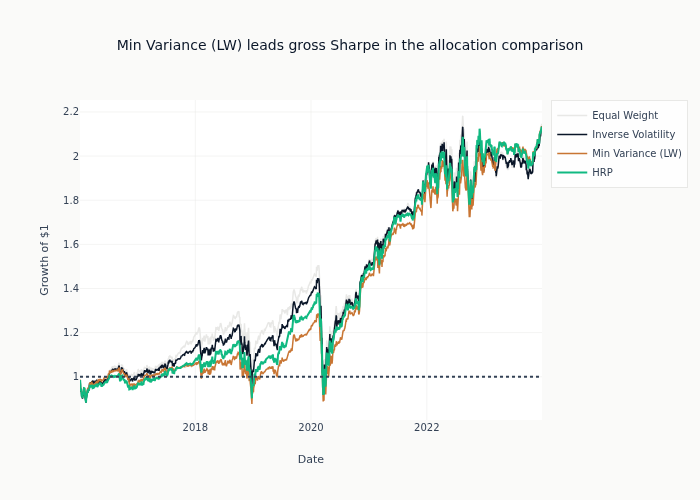

In [40]:
# Equity curves
cumulative = (1 + portfolio_returns).cumprod()

fig = go.Figure()

for col, color in zip(
    cumulative.columns,
    [COLORS["silver_muted"], COLORS["blue"], COLORS["copper"], COLORS["positive"]],
    strict=False,
):
    fig.add_trace(
        go.Scatter(
            x=cumulative.index,
            y=cumulative[col],
            mode="lines",
            name=col,
            line=dict(color=color, width=2 if col == "HRP" else 1.5),
        )
    )

fig.add_hline(y=1.0, line_dash="dot", line_color=COLORS["neutral"])

best_method = metrics_df.loc[metrics_df["Sharpe Ratio"].idxmax(), "Method"]

fig.update_layout(
    title=f"{best_method} leads gross Sharpe in the allocation comparison",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=500,
)
fig.show()

## 10. The HRP series on its own terms

The table above compares allocators to each other. The dashboard below looks at one of them -
HRP - the way an investor would: cumulative growth against SPY, the underwater curve, rolling
Sharpe, and the monthly return grid. Its metrics come from the same return series as the table,
so the two agree to rounding; what it adds is the path behind the summary statistics.

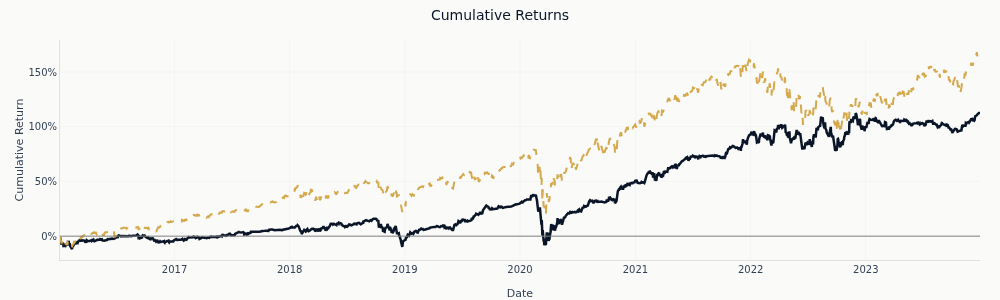

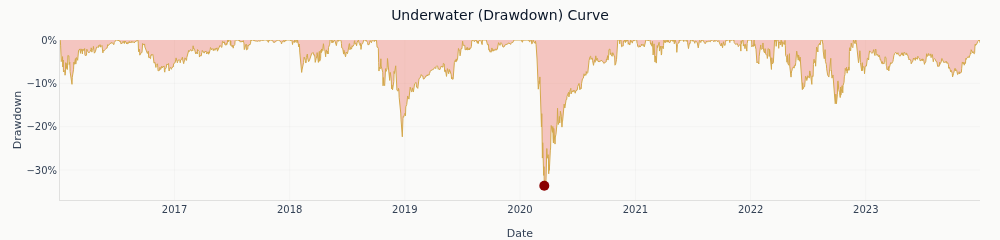

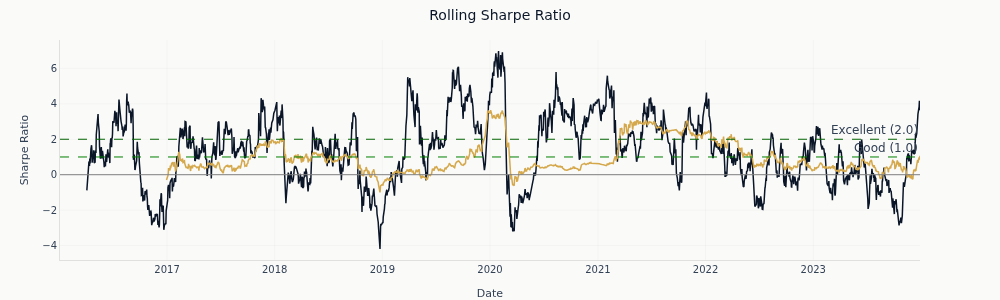

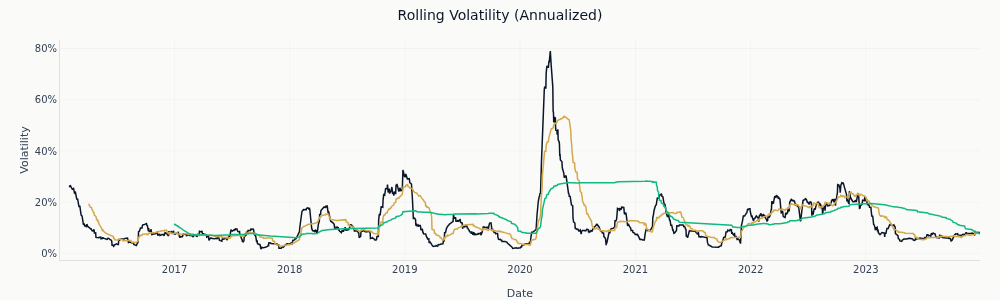

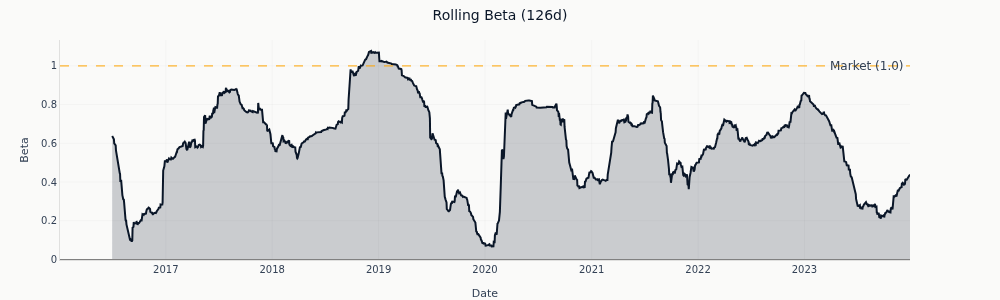

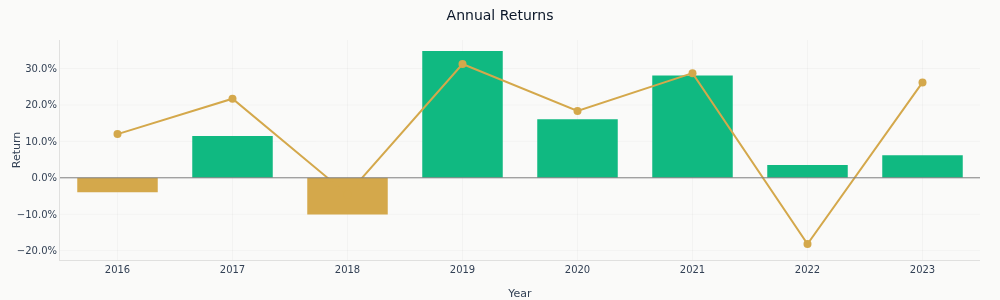

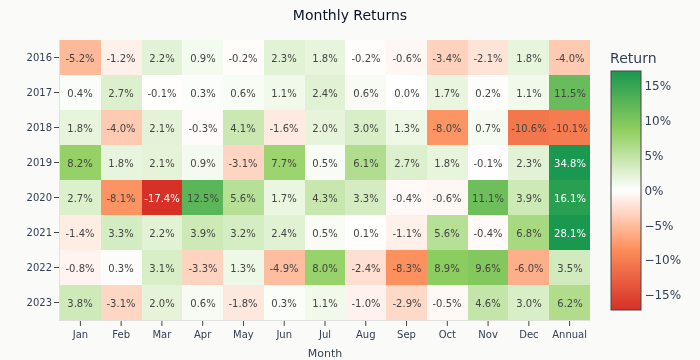

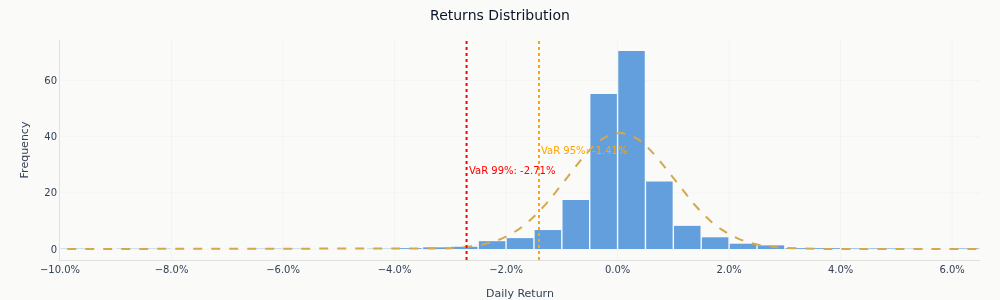

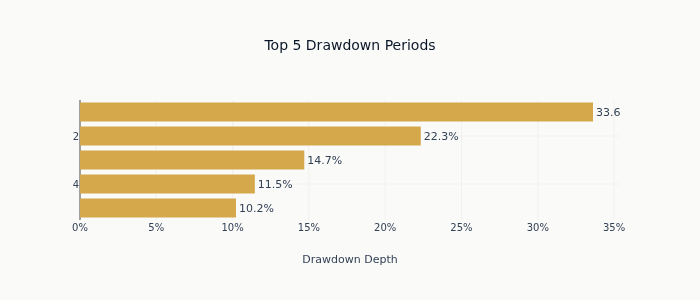

In [41]:
hrp_returns_series = portfolio_returns["HRP"].dropna()
spy_returns_series = returns["SPY"].reindex(hrp_returns_series.index).dropna()
common_idx = hrp_returns_series.index.intersection(spy_returns_series.index)

hrp_analysis = PortfolioAnalysis(
    returns=hrp_returns_series.loc[common_idx].to_numpy(),
    benchmark=spy_returns_series.loc[common_idx].to_numpy(),
    dates=common_idx,
    risk_free=0.0,
    periods_per_year=252,
)

hrp_tear_sheet = create_portfolio_dashboard(hrp_analysis)

for dashboard_figure in hrp_tear_sheet.figures.values():
    dashboard_figure.update_layout(
        paper_bgcolor=COLORS["bg_light"],
        plot_bgcolor=COLORS["bg_light"],
        font_color=COLORS["neutral"],
    )

rolling_beta_figure = hrp_tear_sheet.figures["Rolling Beta"]
rolling_beta_figure.update_layout(margin=dict(l=60, r=90, t=40, b=40))
rolling_beta_figure.update_annotations(x=0.995, xanchor="right")

# Inline display: metrics summary + each constituent figure as a separate cell.
hrp_tear_sheet.show()

In [42]:
# HTML delivery: the same content as a single self-contained file.
output_dir = get_output_dir(17, "hrp")
output_dir.mkdir(parents=True, exist_ok=True)
hrp_tear_sheet_path = output_dir / "hrp_tear_sheet.html"
hrp_tear_sheet.save_html(hrp_tear_sheet_path, include_plotlyjs="cdn")
print(f"HRP tear sheet saved: {output_dir.name}/{hrp_tear_sheet_path.name}")
print(f"  Figures embedded: {list(hrp_tear_sheet.figures.keys())}")

HRP tear sheet saved: hrp/hrp_tear_sheet.html
  Figures embedded: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


## 11. Weight Evolution in Strategy Context

Analyze how the submitted HRP targets change over the walk-forward backtest. The portfolio holds
each allocation until the next month-end decision, so realized weights drift between targets.

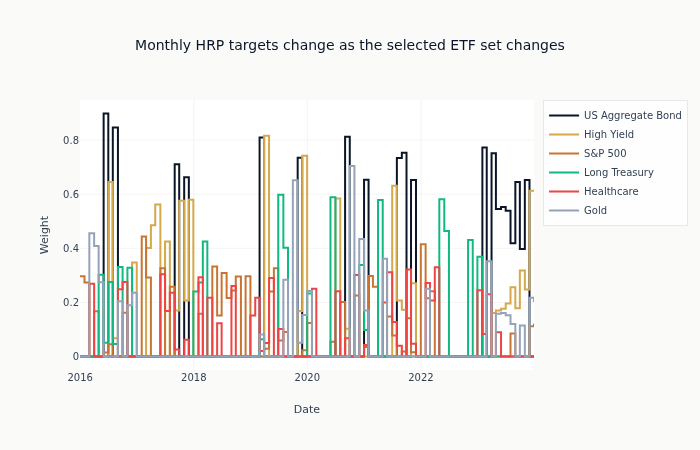

In [43]:
# Plot HRP weight evolution from actual backtest
hrp_weights_hist = weights_all.get("HRP", pd.DataFrame())

if not hrp_weights_hist.empty:
    # Get weight columns
    weight_cols = [c for c in hrp_weights_hist.columns if c.startswith("w_")]

    fig = go.Figure()

    # Show top assets by average weight
    avg_weights = hrp_weights_hist[weight_cols].mean().sort_values(ascending=False)
    top_cols = avg_weights.head(6).index.tolist()

    for col in top_cols:
        symbol = col.replace("w_", "")
        fig.add_trace(
            go.Scatter(
                x=hrp_weights_hist.index,
                y=hrp_weights_hist[col],
                mode="lines",
                name=ETF_UNIVERSE.get(symbol, symbol),
                line_shape="hv",
            )
        )

    fig.update_layout(
        title="Monthly HRP targets change as the selected ETF set changes",
        xaxis_title="Date",
        yaxis_title="Weight",
        height=450,
    )
    fig.show()
else:
    print("No HRP weights available")

The step lines show submitted targets only. Actual portfolio weights drift with asset returns
between month-end decisions; neither the vectorized path nor the execution engine resets them
during the month.

## 12. Reading the Result

The comparison above is the notebook's evidence, so the first thing to do with it is to say
where HRP landed rather than to restate what HRP is supposed to achieve.

In [44]:
ranked = metrics_df.sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)
for rank, row in ranked.iterrows():
    print(
        f"  {rank + 1}. {row['Method']:<19} Sharpe {row['Sharpe Ratio']:>6.3f}   "
        f"vol {row['Annual Vol']:>6.1%}   turnover {row['Avg Turnover']:>7.1%}"
    )
print()
print(f"HRP rank by Sharpe: {int(ranked.index[ranked['Method'] == 'HRP'][0]) + 1} of {len(ranked)}")
print(f"Assets: {n_assets}   estimation window: 252 days   assets selected each month: 5")

  1. Min Variance (LW)   Sharpe  0.735   vol  14.2%   turnover  138.5%
  2. HRP                 Sharpe  0.693   vol  15.3%   turnover  132.9%
  3. Inverse Volatility  Sharpe  0.648   vol  16.6%   turnover  112.0%
  4. Equal Weight        Sharpe  0.631   vol  17.5%   turnover  100.4%

HRP rank by Sharpe: 2 of 4
Assets: 15   estimation window: 252 days   assets selected each month: 5


HRP ranks last. That is the result, and the reason for it is specific.

The argument for HRP is that inverting a noisy covariance matrix amplifies estimation error.
The argument has force when the estimate is badly under-determined, which means when the number
of assets approaches or exceeds the number of observations. This comparison is the opposite
case: five selected assets estimated over 252 daily observations. At that ratio the sample
covariance is well conditioned, its inverse is not dominated by noise, and Ledoit-Wolf shrinkage
cleans up what error remains. HRP uses the correlations only to order the assets and choose the
splits; the weights themselves come from variances. It therefore declines to solve for the
covariance-optimal allocation, and here it is paying that price to avoid an ill-conditioning
problem that this estimate does not have.

The turnover column refuses a second common claim. Clustering is often described as producing
more stable allocations; here HRP turns over more than equal weight and more than inverse
volatility. Most of the turnover in every row comes from the monthly re-selection of five names
out of fifteen, which is identical across allocators - equal weight measures that floor. What
each allocator adds on top of the floor is its own reshuffling, and HRP adds more than the two
simpler methods do.

### What is true regardless of the ranking

These are properties of the algorithm, and they hold wherever it lands in a given sample:

- It never inverts a covariance matrix, so it returns weights for any $N$ and $T$, including
  $N > T$ where minimum-variance optimization has no unique solution at all.
- It needs no expected-return forecast. Every input is second-moment.
- Its weights are determined by the correlation hierarchy and the variances, so they can be
  traced back to a specific split, as section 7 traced them.

### What this notebook cannot tell you

One universe, one sample, one estimation window, and a selection step evaluated on validation
data. A ranking under those conditions is a fact about this run. The regime where HRP was
designed to help - many assets relative to observations - is not the regime tested here, so this
result is not evidence against HRP in that regime either.

### How often an allocator had to fall back

When the allocation function raises (e.g., singular covariance), the
walk-forward backtest falls back to equal weights and increments a counter.

In [45]:
print(f"Assets in universe: {n_assets}")
print(
    f"Invested backtest period: {portfolio_returns.index[0].date()} "
    f"to {portfolio_returns.index[-1].date()}"
)
print(f"Asset selection: ETF GBM walk-forward predictions (hash {ETF_GBM_PRED_HASH})")
if fallback_count:
    print("Allocator fallbacks (singular/invalid covariance):")
    for method_name, count in sorted(fallback_count.items()):
        print(f"  {method_name}: {count}")
else:
    print("Allocator fallbacks: none triggered")

Assets in universe: 15
Invested backtest period: 2016-01-04 to 2023-12-29
Asset selection: ETF GBM walk-forward predictions (hash cb56595c80f4)
Allocator fallbacks: none triggered


## Key Takeaways

1. **HRP replaces inversion with ordering and recursive splits.** It still depends on estimated
   correlations and variances, so it reduces the exposure to estimation error rather than
   removing it.
2. **Avoiding inversion pays off when the estimate is under-determined.** With five assets and
   252 observations it is not, and shrinkage MVO leads this comparison. The case for HRP is
   strongest when the number of assets approaches or exceeds the sample length, which is a
   regime this notebook does not test.
3. **HRP concentrates too, on the low-variance assets.** Section 7 traces a majority weight in a
   single bond fund to two successive inverse-variance splits. Risk-based is not the same thing
   as diversified.
4. **Clustering did not stabilize the allocation here.** HRP turned over more than equal weight
   and inverse volatility, over and above the monthly re-selection every method shares.
5. **The comparison is conditional in three ways.** A fixed 15-ETF ex-post universe, gross of
   costs in the vectorized path, and a selection signal ranked on validation data. It shows
   allocation behavior, not an out-of-sample estimate.
6. **Timing and costs need separate evidence.** Targets use returns through each decision date
   and become effective on the next bar; the execution bridge shows what commissions and
   slippage do to the vectorized result.

**Next**: Continue with [`09_allocator_comparison`](09_allocator_comparison.ipynb) for a
controlled comparison under common signal and execution assumptions.